# 18) Web Scraping 

In [1]:
import pandas as pd 
import numpy as np 
from bs4 import BeautifulSoup 
import requests 

In [2]:
requests.get('https://www.ambitionbox.com/list-of-companies?page=1') 

<Response [403]>

In [3]:
# Response [403] - Forbidden response 
# Server is refusing to fulfill the request. This happens if the server detects that the request is coming from a script rather than a browser 
# i.e. Some webpage's server has robot.text which doesn't allow bots 
# So we will use header here , so that the request looks like it is made from a browser 

In [4]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:81.0) Gecko/20100101 Firefox/81.0",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.5",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1"
}


In [5]:
# Accessing webpage using header 
webpage=requests.get('https://www.ambitionbox.com/list-of-companies?page=34',headers=headers).text

'<!doctype html>\n<html data-n-head-ssr lang="en" data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D">\n  <head >\n    <meta charset="UTF-8">\n    <meta name="viewport" content="width=device-width,initial-scale=1,minimum-scale=1">\n    <meta http-equiv="X-UA-Compatible" content="IE=edge"> \n    <style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>\n    <script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>\n    <script type="text/partytown">\n      window.dataLayer = window.dataLayer || [];\n      window.gtag = function() {\n      \twindow.dataLayer.push(arguments);\n      };\n      gtag(\'js\', new Date(window.initialDate));\n    </script>\n    <title>List of companies in India | AmbitionBox</title><meta data-n-head="ssr" name="copyright" content="2024 AmbitionBox"><meta data-n-head="ssr" 
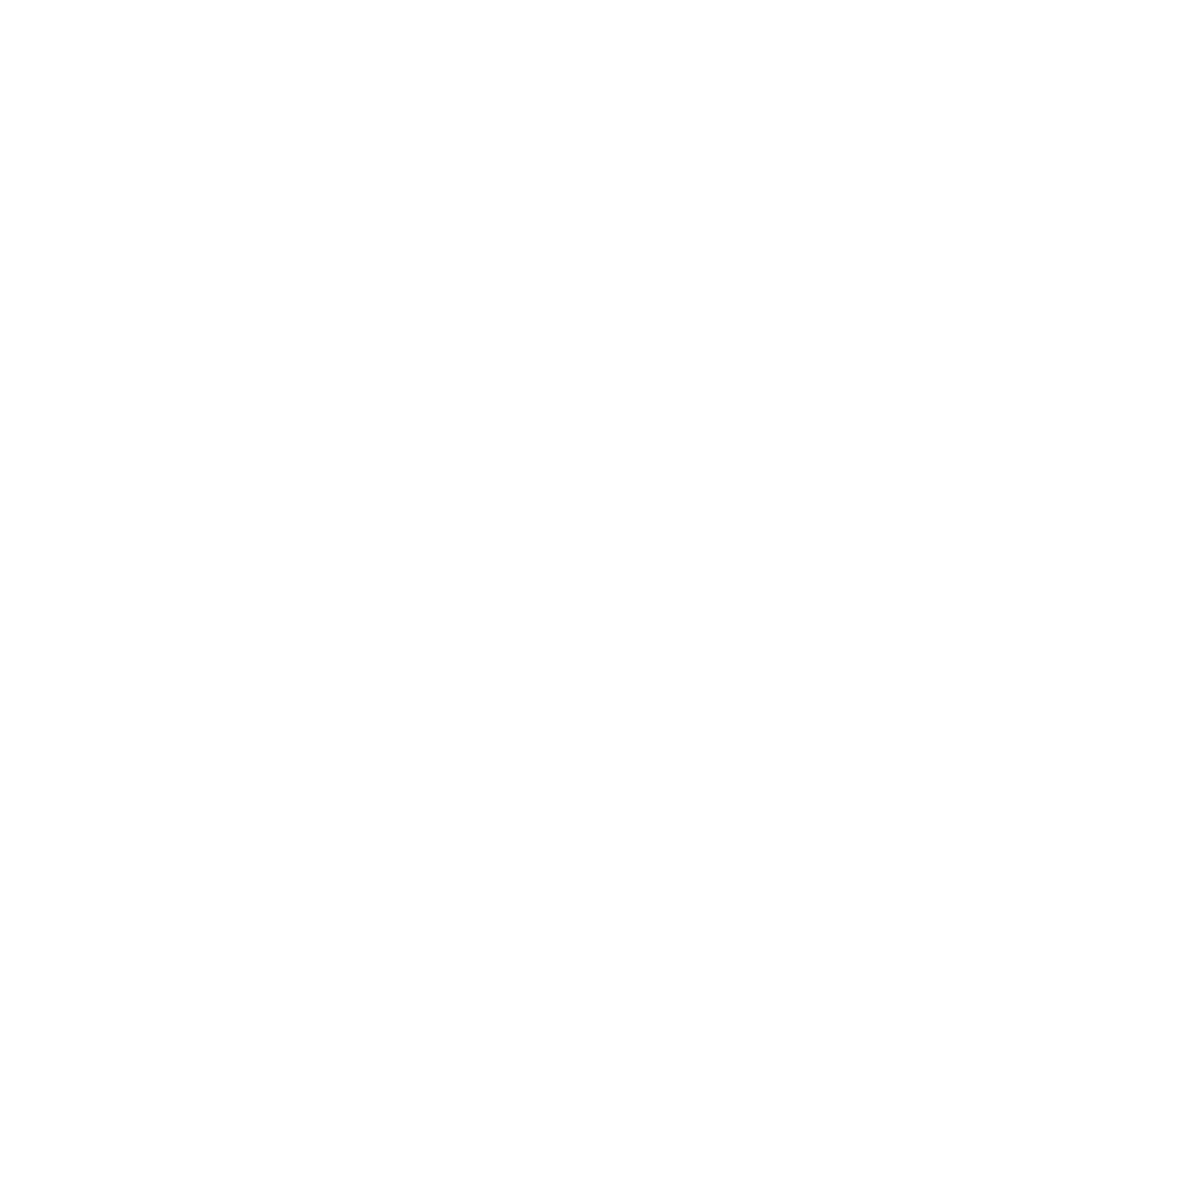

In [6]:
webpage

In [7]:
soup=BeautifulSoup(webpage,'html.parser') 

<!DOCTYPE html>

<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>
<script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>
<script type="text/partytown">
      window.dataLayer = window.dataLayer || [];
      window.gtag = function() {
      	window.dataLayer.push(arguments);
      };
      gtag('js', new Date(window.initialDate));
    </script>
<title>List of companies in India | AmbitionBox</title><meta content="2024 AmbitionBox" data-n-head="ssr" name="copyright"/><meta content="1 day" data-n-head="ssr" name="revisit-after"/><meta
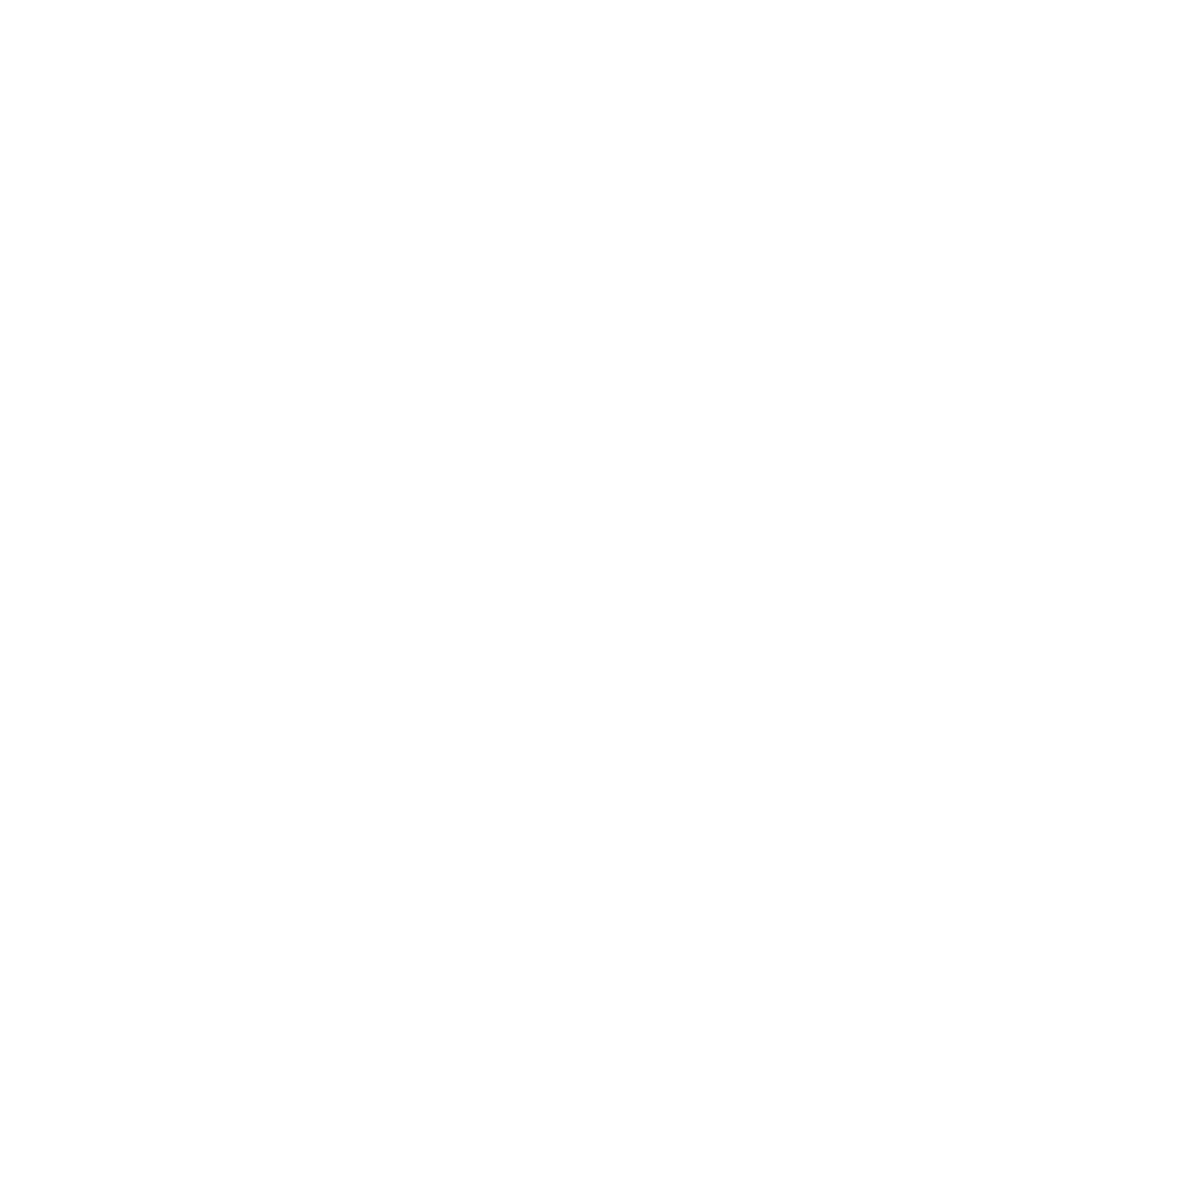

In [8]:
soup

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <style>
   @media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}
  </style>
  <script>
   window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()
  </script>
  <script type="text/partytown">
   window.dataLayer = window.dataLayer || [];
      window.gtag = function() {
      	window.dataLayer.push(arguments);
      };
      gtag('js', new Date(window.initialDate));
  </script>
  <title>
   List of companies in India | AmbitionBox
  </title>
  <meta content="2024 AmbitionBox" data-n-head="ssr" name="copyright"/>
  <meta content="1 day" data-n-he
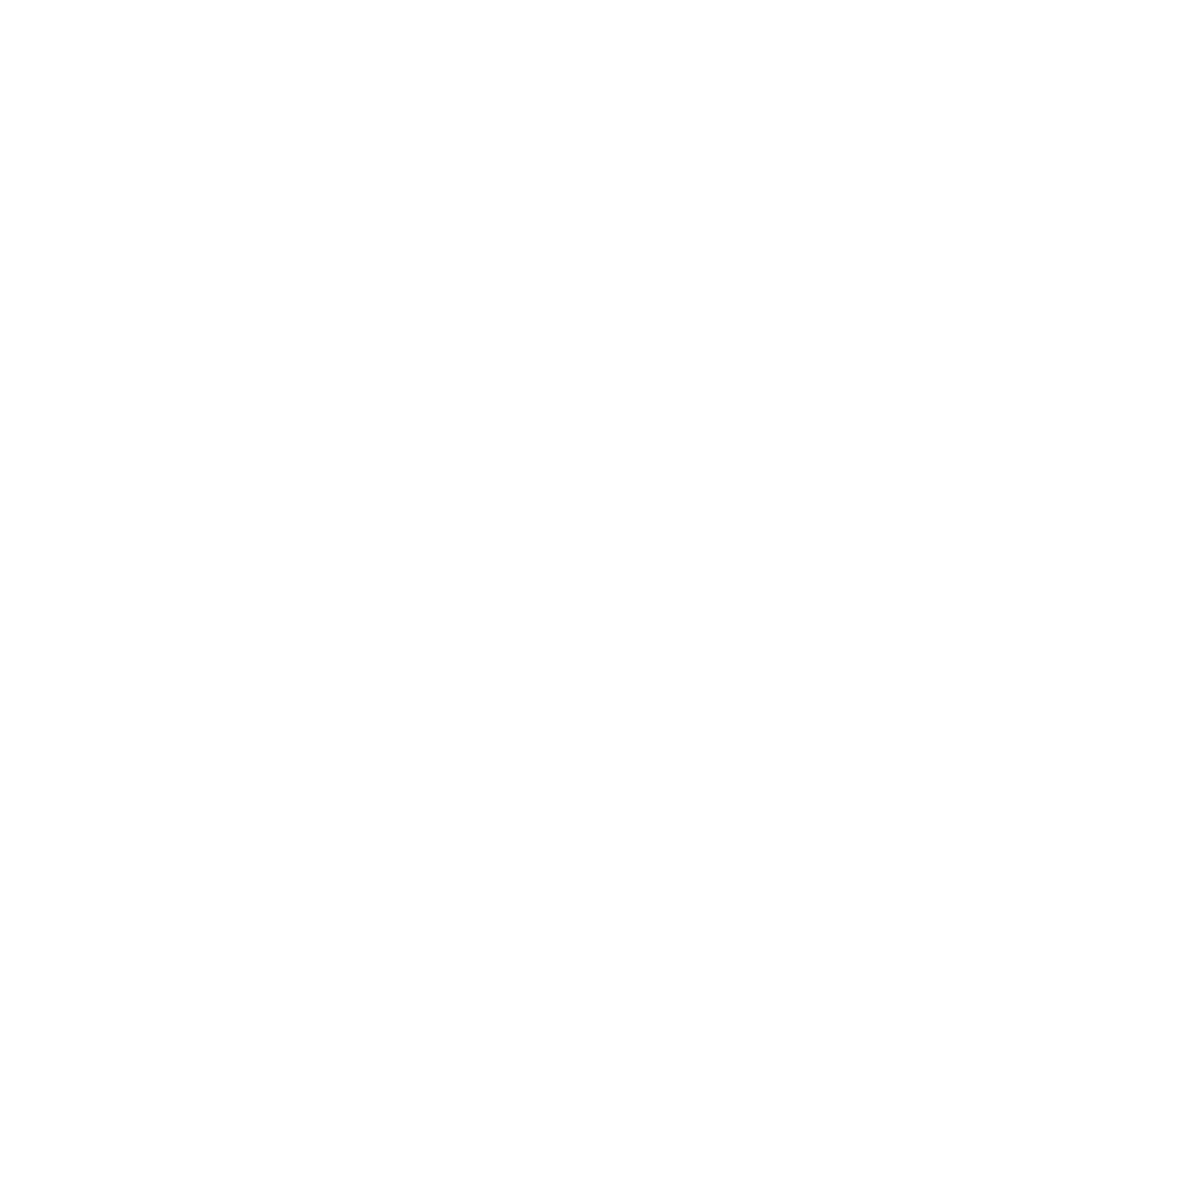

In [9]:
print(soup.prettify())

In [10]:
# The prettify() method will turn a Beautiful Soup parse tree into a nicely formatted Unicode string, with a separate line for each tag and each string

# Filtering out Company Name 

In [11]:
soup.find_all('h1')

[<h1 class="companyListing__title">
 							List of companies in India
 						</h1>]

In [12]:
soup.find_all('h1')[0].text

# .text removes all the tags except the escape sequences 

'\n\t\t\t\t\t\t\tList of companies in India\n\t\t\t\t\t\t'

In [13]:
# Strip function :  (Removes the escape sequence as well)   
soup.find_all('h1')[0].text.strip()

'List of companies in India'

In [14]:
# h2 tag contains list of all the companies 
soup.find_all('h2')

[<h2 class="companyCardWrapper__companyName" title="Lavender Technology">
 										Lavender Technology
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Paytm Payments Bank">
 										Paytm Payments Bank
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Cushman &amp; Wakefield">
 										Cushman &amp; Wakefield
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Granules India">
 										Granules India
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Caterpillar Inc">
 										Caterpillar Inc
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="J. Kumar Infraprojects">
 										J. Kumar Infraprojects
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="GMR Group">
 										GMR Group
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Godrej Group">
 										Godrej Group
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Nayara Ene

In [15]:
# h2 tag contains list of all the companies 
soup.find_all('h2',class_="companyCardWrapper__companyName")

[<h2 class="companyCardWrapper__companyName" title="Lavender Technology">
 										Lavender Technology
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Paytm Payments Bank">
 										Paytm Payments Bank
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Cushman &amp; Wakefield">
 										Cushman &amp; Wakefield
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Granules India">
 										Granules India
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Caterpillar Inc">
 										Caterpillar Inc
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="J. Kumar Infraprojects">
 										J. Kumar Infraprojects
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="GMR Group">
 										GMR Group
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Godrej Group">
 										Godrej Group
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Nayara Ene

In [16]:
# to verify that h2 contains all the companies list , we can use len function 
len(soup.find_all('h2'))

24

In [17]:
# answer is 24 , but we have only 20 companies in list , which means h2 tag contains other information as well

In [18]:
soup.find_all('h2')[0] 

<h2 class="companyCardWrapper__companyName" title="Lavender Technology">
										Lavender Technology
									</h2>

In [19]:
soup.find_all('h2')[1]

<h2 class="companyCardWrapper__companyName" title="Paytm Payments Bank">
										Paytm Payments Bank
									</h2>

In [20]:
soup.find_all('h2')[2].text.strip()

'Cushman & Wakefield'

In [21]:
# extracting all the values from h2 :
for i in soup.find_all('h2') :
    print(i)

<h2 class="companyCardWrapper__companyName" title="Lavender Technology">
										Lavender Technology
									</h2>
<h2 class="companyCardWrapper__companyName" title="Paytm Payments Bank">
										Paytm Payments Bank
									</h2>
<h2 class="companyCardWrapper__companyName" title="Cushman &amp; Wakefield">
										Cushman &amp; Wakefield
									</h2>
<h2 class="companyCardWrapper__companyName" title="Granules India">
										Granules India
									</h2>
<h2 class="companyCardWrapper__companyName" title="Caterpillar Inc">
										Caterpillar Inc
									</h2>
<h2 class="companyCardWrapper__companyName" title="J. Kumar Infraprojects">
										J. Kumar Infraprojects
									</h2>
<h2 class="companyCardWrapper__companyName" title="GMR Group">
										GMR Group
									</h2>
<h2 class="companyCardWrapper__companyName" title="Godrej Group">
										Godrej Group
									</h2>
<h2 class="companyCardWrapper__companyName" title="Nayara Energy">
										Nayara Energy
			

In [22]:
for i in range(20) :
    a=soup.find_all('h2')
    print(a[i].text.strip()) 

# We are using 20 , becoz only the first 20 elements of h2 tag are company name 

Lavender Technology
Paytm Payments Bank
Cushman & Wakefield
Granules India
Caterpillar Inc
J. Kumar Infraprojects
GMR Group
Godrej Group
Nayara Energy
Annapurna Finance
Broadridge Financial Solutions
GE
Inox Leisure
SRL Diagnostics
Aditya Birla Health Insurance Co
Evalueserve
Xiaomi
Canara Bank
VLCC
Sanofi


In [23]:
# In the span tag , the company rating is contained in "companyCardWrapper__companyRatingValue" class
soup.find_all('span',class_='companyCardWrapper__companyRatingValue') 

[<span class="companyCardWrapper__companyRatingValue">5.0</span>,
 <span class="companyCardWrapper__companyRatingValue">3.9</span>,
 <span class="companyCardWrapper__companyRatingValue">4.2</span>,
 <span class="companyCardWrapper__companyRatingValue">3.9</span>,
 <span class="companyCardWrapper__companyRatingValue">4.2</span>,
 <span class="companyCardWrapper__companyRatingValue">4.1</span>,
 <span class="companyCardWrapper__companyRatingValue">4.1</span>,
 <span class="companyCardWrapper__companyRatingValue">4.0</span>,
 <span class="companyCardWrapper__companyRatingValue">4.2</span>,
 <span class="companyCardWrapper__companyRatingValue">4.1</span>,
 <span class="companyCardWrapper__companyRatingValue">4.0</span>,
 <span class="companyCardWrapper__companyRatingValue">4.3</span>,
 <span class="companyCardWrapper__companyRatingValue">4.1</span>,
 <span class="companyCardWrapper__companyRatingValue">4.1</span>,
 <span class="companyCardWrapper__companyRatingValue">3.9</span>,
 <span cla

In [24]:
for i in soup.find_all('span',class_='companyCardWrapper__companyRatingValue') :
    print(i.text)

5.0
3.9
4.2
3.9
4.2
4.1
4.1
4.0
4.2
4.1
4.0
4.3
4.1
4.1
3.9
3.4
3.9
3.5
3.7
4.4


In [25]:
soup.find_all("span",class_="companyCardWrapper__interLinking")

[<span class="companyCardWrapper__interLinking">
 									IT Services &amp; Consulting | 5k-10k Employees | 14 years old | USA +4 more
 								</span>,
 <span class="companyCardWrapper__interLinking">
 									FinTech | 1k-5k Employees | Public | 8 years old | Noida +110 more
 								</span>,
 <span class="companyCardWrapper__interLinking">
 									Real Estate | 1k-5k Employees | 107 years old | Chicago +38 more
 								</span>,
 <span class="companyCardWrapper__interLinking">
 									Pharma | 1k-5k Employees | Public | 40 years old | Hyderabad/Secunderabad +14 more
 								</span>,
 <span class="companyCardWrapper__interLinking">
 									Industrial Machinery | 5k-10k Employees | Forbes Global 2000 | 99 years old | Deerfield +34 more
 								</span>,
 <span class="companyCardWrapper__interLinking">
 									Engineering &amp; Construction | 5k-10k Employees | Public | 44 years old | Mumbai +31 more
 								</span>,
 <span class="companyCardWrapper__interLinking">
 							

In [26]:
len(soup.find_all("span",class_="companyCardWrapper__interLinking")) 

20

In [27]:
for i in soup.find_all("span",class_="companyCardWrapper__interLinking") :
    print(i.text.strip())

IT Services & Consulting | 5k-10k Employees | 14 years old | USA +4 more
FinTech | 1k-5k Employees | Public | 8 years old | Noida +110 more
Real Estate | 1k-5k Employees | 107 years old | Chicago +38 more
Pharma | 1k-5k Employees | Public | 40 years old | Hyderabad/Secunderabad +14 more
Industrial Machinery | 5k-10k Employees | Forbes Global 2000 | 99 years old | Deerfield +34 more
Engineering & Construction | 5k-10k Employees | Public | 44 years old | Mumbai +31 more
Engineering & Construction | 10k-50k Employees | Public | 46 years old | Delhi/NCR +55 more
Chemicals | 10k-50k Employees | Public | 127 years old | Mumbai +116 more
Petrochemicals | 1k-5k Employees | Fortune India 500 | 35 years old | Mumbai +77 more
NBFC | 5k-10k Employees | 15 years old | Bhubaneswar +283 more
FinTech | 5k-10k Employees | Forbes Global 2000 | 17 years old | New York City +9 more
Defence & Aerospace | 10k-50k Employees | Forbes Global 2000 | 132 years old | Boston +64 more
Media & Entertainment | 1k-5k 

In [28]:
soup.find_all("span",class_="companyCardWrapper__interLinking")[0].text 

'\n\t\t\t\t\t\t\t\t\tIT Services & Consulting | 5k-10k Employees | 14 years old | USA +4 more\n\t\t\t\t\t\t\t\t'

In [29]:
soup.find_all("span",class_="companyCardWrapper__interLinking")[0].text.strip() 

'IT Services & Consulting | 5k-10k Employees | 14 years old | USA +4 more'

In [39]:
web=requests.get('https://www.ambitionbox.com/list-of-companies?sortBy=rating&page=45',headers=headers).text

'<!doctype html>\n<html data-n-head-ssr lang="en" data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D">\n  <head >\n    <meta charset="UTF-8">\n    <meta name="viewport" content="width=device-width,initial-scale=1,minimum-scale=1">\n    <meta http-equiv="X-UA-Compatible" content="IE=edge"> \n    <style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>\n    <script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>\n    <script type="text/partytown">\n      window.dataLayer = window.dataLayer || [];\n      window.gtag = function() {\n      \twindow.dataLayer.push(arguments);\n      };\n      gtag(\'js\', new Date(window.initialDate));\n    </script>\n    <title>List of companies in India | AmbitionBox</title><meta data-n-head="ssr" name="copyright" content="2024 AmbitionBox"><meta data-n-head="ssr" 
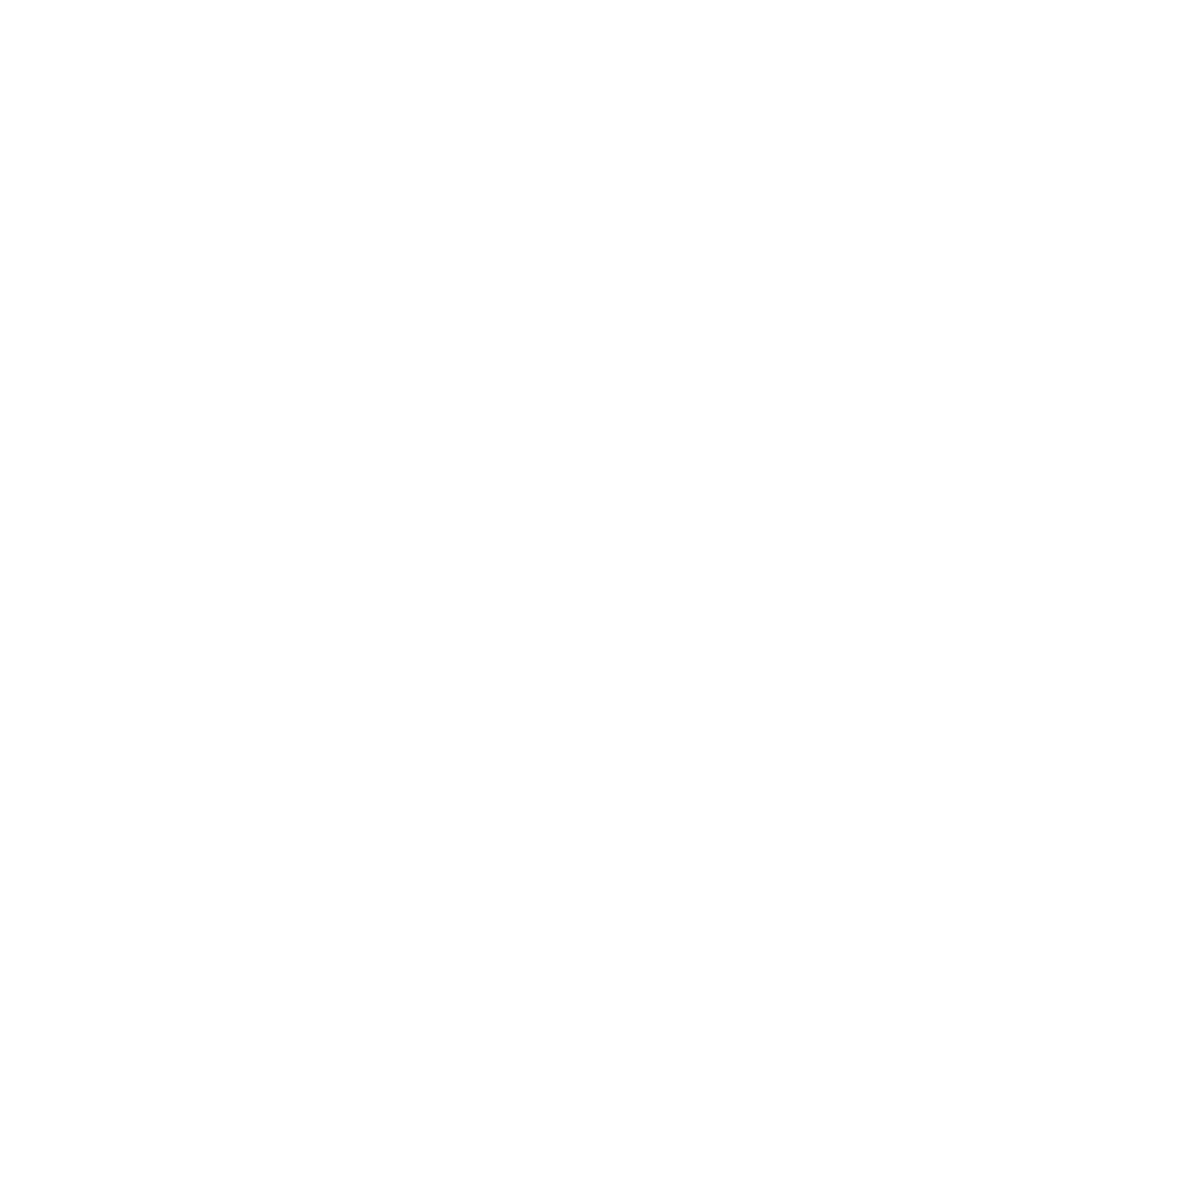

In [41]:
web

In [43]:
 soup1=BeautifulSoup(web)

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>
<script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>
<script type="text/partytown">
      window.dataLayer = window.dataLayer || [];
      window.gtag = function() {
      	window.dataLayer.push(arguments);
      };
      gtag('js', new Date(window.initialDate));
    </script>
<title>List of companies in India | AmbitionBox</title><meta content="2024 AmbitionBox" data-n-head="ssr" name="copyright"/><meta content="1 day" data-n-head="ssr" name="revisit-after"/><meta 
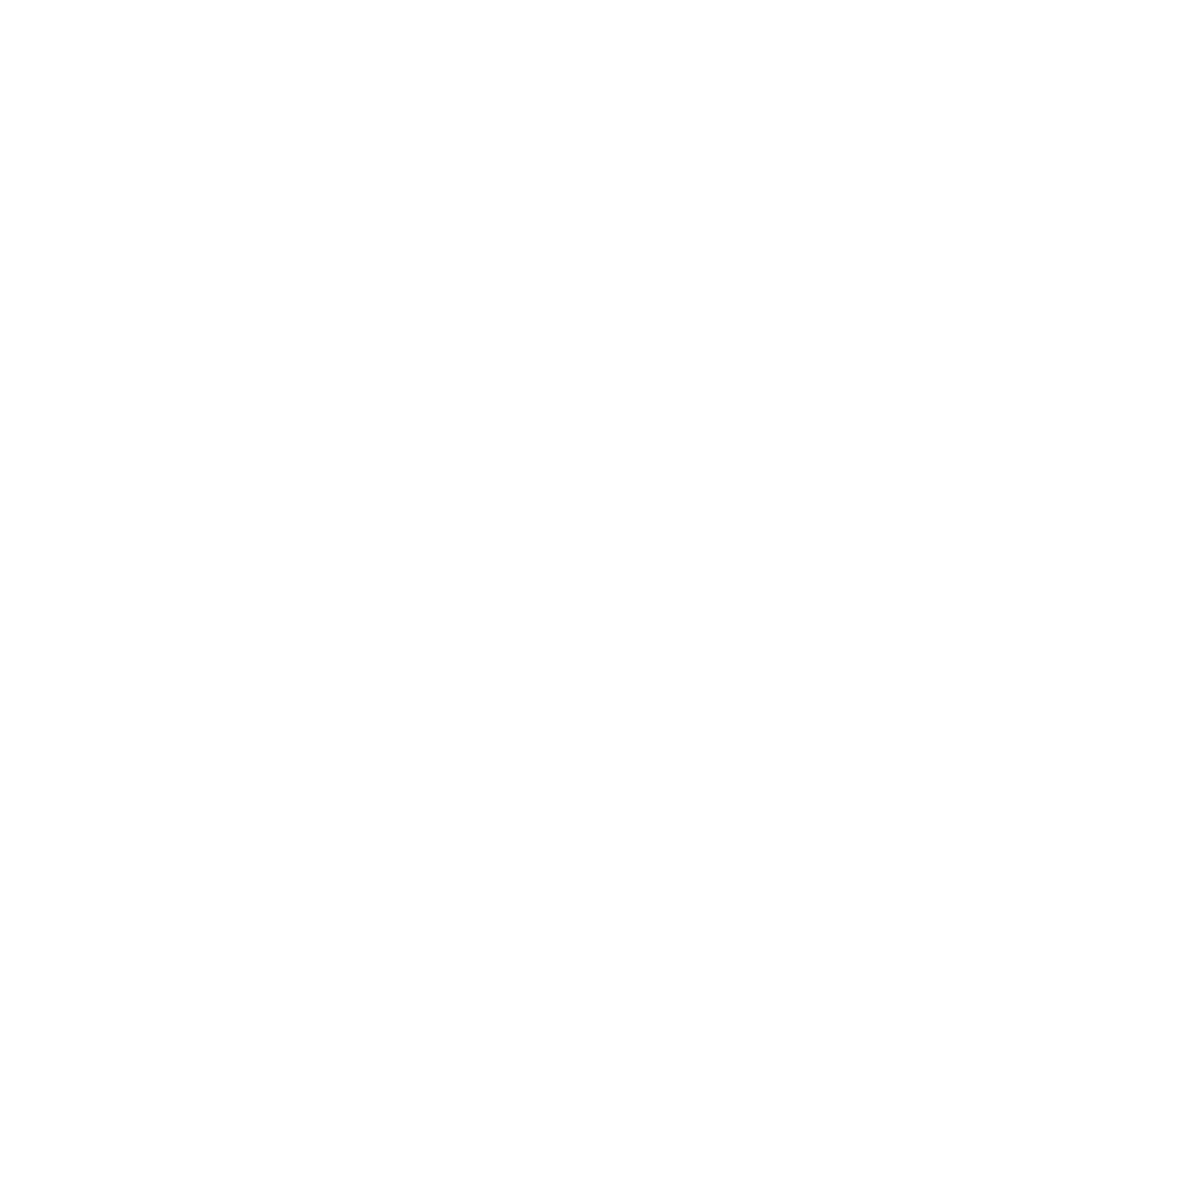

In [44]:
soup1

In [46]:
rn=soup1.find_all('span',class_='companyCardWrapper__ratingValues')

In [47]:
len(rn)

22

In [50]:
for i in rn :
    print(i.text.strip())

Skill Development / Learning, Company Culture, Work Life Balance
Company Culture, Work Life Balance, Work Satisfaction
Promotions / Appraisal, Skill Development / Learning, Company Culture
Company Culture, Work Satisfaction, Skill Development / Learning
Promotions / Appraisal, Salary & Benefits
Job Security, Work Satisfaction, Company Culture
Company Culture, Work Life Balance, Work Satisfaction
Work Satisfaction, Promotions / Appraisal
Skill Development / Learning, Work Life Balance, Salary & Benefits
Promotions / Appraisal
Company Culture, Work Life Balance, Work Satisfaction
Work Life Balance, Job Security, Company Culture
Skill Development / Learning, Work Life Balance, Job Security
Work Life Balance, Job Security, Skill Development / Learning
Company Culture, Job Security, Work Satisfaction
Work Life Balance, Work Satisfaction, Job Security
Promotions / Appraisal, Skill Development / Learning, Job Security
Promotions / Appraisal, Work Satisfaction, Skill Development / Learning
Wor

In [53]:
rn[9]

<span class="companyCardWrapper__ratingValues">Promotions / Appraisal</span>